## HIT140 - WC2026. Did players on teams that advanced past the group stage show a bigger gap in penetrative passing (linebreaks) or safe passing (accuracy) compared to players on teams eliminated in the group stage?
Most people judge a team by pass completion rate. How many passed find a teammate. But a safe pase isn't the same as dangerous one: a team can complete 95% of its passes while barely being on a opposition side, if none of these passes actually break through the defensive line. So lets see if this myth is true. I separate players into two groups based on tournament outcome. Those on teams that advanced past the group stage (32 teams) versus those eliminated in the group stage (16 teams). This isn't a clean split. Group draws are seeded, not random so 'advanced' reflects group difficulty, not just team quality.

I initially reverse-engineereed FIFA's authenticated internal API (via DevTools network inspection, extracting the bearer token used by official site) to scrape players stats directly. This scraped most of the stats we wanted, but still had some gap. We thought for going for Fbref which introduced cross-source name-matching problem.
We later identified the FIFA also exposes unauthenticated public endpoints serving the same data with all the stats we wanted, which eliminated the need of joining the data from two sources.
Before solely adapting this data source, lets validate against our old scraper which directly scraped from official website's endpoints.

In [35]:
# Data scraped from old scraper
import pandas as pd
dist = pd.read_csv("wc026_distribution.csv")
print(dist.shape)
print(dist.columns.tolist())

(1813, 14)
['name', 'shirt', 'team', 'passes', 'passes_completed', 'passing_accuracy_rate', 'crosses', 'crossing_accuracy_rate', 'take_ons_completed', 'linebreaks_attempted_defensive_line', 'linebreak_attempted_defensive_line_rate', 'attempted_switches_of_play', 'switches_of_play_rate', 'position']


In [34]:
import requests
import time
r = requests.get("https://api.fifa.com/api/v3/teamsqualified/season/285023",
                  params={"language": "en", "count": 100}, headers=headers)
teams_data = r.json()
code_to_id = {t["IdCountry"]: t["IdTeam"] for t in teams_data["Results"]}

name_to_id = {}
for code, team_id in code_to_id.items():
    r = requests.get(f"https://api.fifa.com/api/v3/teams/{team_id}/squad",
                      params={"idCompetition": 17, "idSeason": 285023, "language": "en"},
                      headers=headers)
    squad = r.json()
    for p in squad["Players"]:
        pname = p["PlayerName"][0]["Description"].upper()
        name_to_id[(code, pname)] = p["IdPlayer"]
    time.sleep(0.1)

print(len(code_to_id), len(name_to_id))

48 1248


The API has a id rather than explicit names, we have stored team code and player's code to compare.

In [40]:
import random

dist_played = dist[dist['passes']>0].copy()
random.seed(42)
sample = dist_played.sample(15, random_state=42)

matched, unmatched = [], []
for _, row in sample.iterrows():
    key = (row["team"], row["name"].upper())
    if key in name_to_id:
        pid = name_to_id[key]
        api_stats = {f[0]: f[1] for f in players_data[pid]}
        if api_stats.get("TimePlayed", 0) > 0:
            matched.append((row, pid))
        else:
            unmatched.append((row["name"], "0 minutes played"))
    else:
        unmatched.append((row["name"], "no name match"))

print(f"matched: {len(matched)} / 15")
print("unmatched:", unmatched)

matched: 14 / 15
unmatched: [('Brandon Thomas Asante', 'no name match')]


Before assuming every name would match cleanly, I tested again a raw random sample and found out why it didnt match. Lets see why it didn't match.

In [41]:
row = sample[sample["name"] == "Brandon Thomas Asante"].iloc[0]
team_code = row["team"]

for k in name_to_id:
    if k[0] == team_code and "ASANTE" in k[1]:
        print(k[1])

BRANDON THOMAS-ASANTE


Be assured cause its the hyphens.

In [42]:
results = []
for row, pid in matched:
    api_stats = {f[0]: f[1] for f in players_data[pid]}
    results.append({
        "name": row["name"],
        "old_passes": row["passes"], "new_passes": api_stats.get("Passes"),
        "old_completed": row["passes_completed"], "new_completed": api_stats.get("PassesCompleted"),
        "old_linebreaks": row["linebreaks_attempted_defensive_line"], "new_linebreaks": api_stats.get("LinebreaksAttemptedDefensiveLine"),
    })

comparison = pd.DataFrame(results)
print(comparison)

                   name  old_passes  new_passes  old_completed  new_completed  \
0          Leo Ostigard        99.0          99           84.0             84   
1          Kenny Mclean        63.0          63           56.0             56   
2          Lionel Messi       367.0         367          288.0            288   
3      Deveron Fonville        66.0          66           55.0             55   
4             Tim Payne        87.0          87           72.0             72   
5          Amir Murillo       112.0         112           88.0             88   
6         Sondre Langas        10.0          10            9.0              9   
7   Amir Hadziahmetovic         3.0           3            3.0              3   
8      Evidence Makgopa        29.0          29           20.0             20   
9          Raul Jimenez        66.0          66           48.0             48   
10  Christian Fassnacht         5.0           5            5.0              5   
11       Iqraam Rayners     

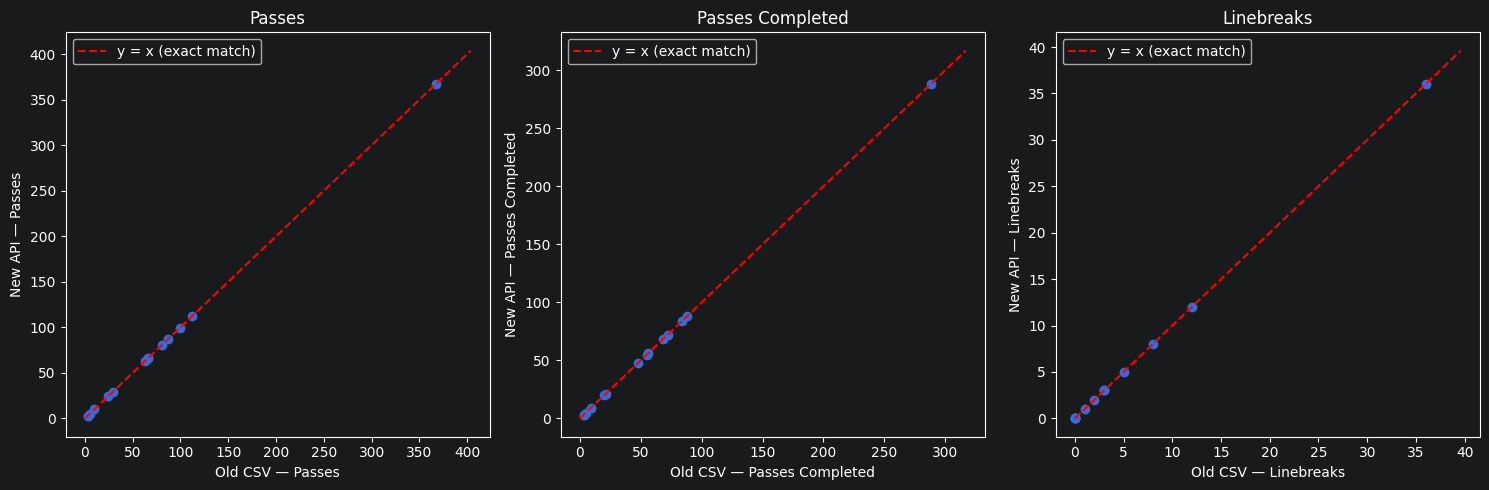

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (old_col, new_col, label) in zip(axes, [
    ("old_passes", "new_passes", "Passes"),
    ("old_completed", "new_completed", "Passes Completed"),
    ("old_linebreaks", "new_linebreaks", "Linebreaks"),
]):
    ax.scatter(comparison[old_col], comparison[new_col])
    lims = [0, max(comparison[old_col].max(), comparison[new_col].max()) * 1.1]
    ax.plot(lims, lims, 'r--', label='y = x (exact match)')
    ax.set_xlabel(f"Old CSV — {label}")
    ax.set_ylabel(f"New API — {label}")
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

The plots display data after a random selection of 14 active players, using two different sources that verified the statistics.

By now, we can say that the API has real stats which will be meaningful in our analysis. This validates the public API can be used as fully reliable signal source of truth.